In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0,'..')
from scripts.utils import Config
from scripts.models.sr.train import load_data, subsample_timestep

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
config = Config()

run_name = "sr_gauss_all"
runconfig = config.sr["runs"][run_name]

subsetfrac = config.sr["subsetfrac"]
seeds = config.sr["seeds"]

targetvar = config.targetvar

In [3]:
def load_train_valid_for_sr(runconfig, config):
    xtrain, ytrain, refdatrain, vmtrain = load_data(
        "train", runconfig, config, time_offset=0
    )

    xvalid, yvalid, _, vmvalid = load_data(
        "valid", runconfig, config, time_offset=int(refdatrain.sizes["time"])
    )

    xfit = pd.concat([xtrain[vmtrain], xvalid[vmvalid]]).reset_index(drop=True)
    yfit = np.concatenate([ytrain[vmtrain], yvalid[vmvalid]])

    return xfit, yfit


def load_stats(config):
    statsfile = os.path.join(config.splitsdir, "stats.json")
    with open(statsfile, "r", encoding="utf-8") as f:
        return json.load(f)


def denorm_tp(y_zlog, stats):
    """
    Converts z-scored log1p(tp) back to native precipitation in mm.
    """
    return np.expm1(y_zlog * stats[f"{targetvar}_std"] + stats[f"{targetvar}_mean"])


def rain_bin_table(tp_full, tp_sub, bins=None):
    if bins is None:
        bins = np.array([0, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, np.inf])

    labels = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        if lo == 0:
            labels.append(f"0 to {hi:g} mm")
        elif np.isinf(hi):
            labels.append(f"> {lo:g} mm")
        else:
            labels.append(f"{lo:g} to {hi:g} mm")

    full_counts = []
    sub_counts = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        if lo == 0:
            full_mask = (tp_full >= lo) & (tp_full <= hi)
            sub_mask = (tp_sub >= lo) & (tp_sub <= hi)
        else:
            full_mask = (tp_full > lo) & (tp_full <= hi)
            sub_mask = (tp_sub > lo) & (tp_sub <= hi)

        full_counts.append(full_mask.sum())
        sub_counts.append(sub_mask.sum())

    table = pd.DataFrame({
        "bin": labels,
        "full_count": full_counts,
        "subset_count": sub_counts,
    })

    table["full_frac"] = table["full_count"] / table["full_count"].sum()
    table["subset_frac"] = table["subset_count"] / table["subset_count"].sum()
    table["subset_over_full_frac"] = table["subset_frac"] / table["full_frac"]

    return table


def summarize_tp(name, tp):
    return pd.Series({
        "n": len(tp),
        "dry_frac_tp_eq_0": np.mean(tp == 0),
        "dry_frac_tp_le_1e-4": np.mean(tp <= 1e-4),
        "mean_mm": np.mean(tp),
        "median_mm": np.median(tp),
        "p90_mm": np.percentile(tp, 90),
        "p95_mm": np.percentile(tp, 95),
        "p99_mm": np.percentile(tp, 99),
        "p99.9_mm": np.percentile(tp, 99.9),
        "max_mm": np.max(tp),
    }, name=name)

In [4]:
# Load full train+valid pool
xfit, yfit = load_train_valid_for_sr(runconfig, config)

# Apply the same timestep subsampling used by SR (using the first seed)
xsub, ysub = subsample_timestep(
    xfit,
    yfit,
    subsetfrac=subsetfrac,
    seed=seeds[0],
)

stats = load_stats(config)

tp_full = denorm_tp(yfit, stats)
tp_sub = denorm_tp(ysub, stats)

print(f"Run: {run_name}")
print(f"Full train+valid samples: {len(tp_full):,}")
print(f"SR subset samples:        {len(tp_sub):,}")
print(f"Subset fraction (requested):  {subsetfrac:.4%}")
print(f"Subset fraction (actual):     {len(tp_sub) / len(tp_full):.4%}")

Run: sr_gauss_all
Full train+valid samples: 8,624,448
SR subset samples:        216,132
Subset fraction (requested):  2.5000%
Subset fraction (actual):     2.5060%


In [5]:
summary = pd.concat([
    summarize_tp("full_train_valid", tp_full),
    summarize_tp("sr_subset", tp_sub),
], axis=1)

summary

,full_train_valid,sr_subset
n,8.624448e+06,216132.000000
dry_frac_tp_eq_0,1.898787e-01,0.190388
dry_frac_tp_le_1e-4,1.898787e-01,0.190388
mean_mm,7.241611e-01,0.726998
median_mm,9.221584e-02,0.091631
p90_mm,2.067361e+00,2.119586
p95_mm,3.678840e+00,3.713014
p99_mm,8.494395e+00,8.351745
p99.9_mm,2.150236e+01,20.492511
max_mm,1.394075e+02,98.566071


In [6]:
bin_table = rain_bin_table(tp_full, tp_sub)
bin_table

,bin,full_count,subset_count,full_frac,subset_frac,subset_over_full_frac
0,0 to 1e-06 mm,1637599,41149,0.189879,0.190388,1.002684
1,1e-06 to 0.0001 mm,0,0,0.000000,0.000000,NaN
2,0.0001 to 0.001 mm,166253,4135,0.019277,0.019132,0.992472
3,0.001 to 0.01 mm,756067,19293,0.087666,0.089265,1.018244
4,0.01 to 0.1 mm,1843356,45861,0.213736,0.212190,0.992765
5,0.1 to 1 mm,2723913,67328,0.315836,0.311513,0.986313
6,1 to 10 mm,1438446,36969,0.166787,0.171048,1.025549
7,10 to 100 mm,58798,1397,0.006818,0.006464,0.948082
8,> 100 mm,16,0,0.000002,0.000000,0.000000


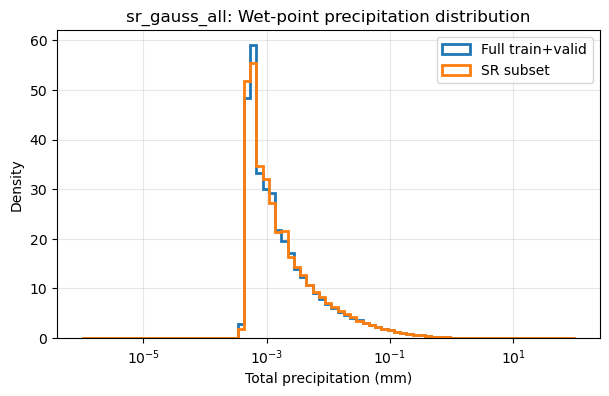

Full dry fraction tp == 0: 18.988%
Subset dry fraction tp == 0: 19.039%
Full dry fraction tp <= 1e-4 mm: 18.988%
Subset dry fraction tp <= 1e-4 mm: 19.039%


In [7]:
# Histogram comparison in native precipitation space.
# Use log-spaced wet bins plus a separate dry count annotation.

wet_full = tp_full[tp_full > 0]
wet_sub = tp_sub[tp_sub > 0]

bins = np.logspace(-6, 2, 80)

plt.figure(figsize=(7, 4))
plt.hist(wet_full, bins=bins, density=True, histtype="step", linewidth=2, label="Full train+valid")
plt.hist(wet_sub, bins=bins, density=True, histtype="step", linewidth=2, label="SR subset")
plt.xscale("log")
plt.xlabel("Total precipitation (mm)")
plt.ylabel("Density")
plt.title(f"{run_name}: Wet-point precipitation distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Full dry fraction tp == 0: {np.mean(tp_full == 0):.3%}")
print(f"Subset dry fraction tp == 0: {np.mean(tp_sub == 0):.3%}")
print(f"Full dry fraction tp <= 1e-4 mm: {np.mean(tp_full <= 1e-4):.3%}")
print(f"Subset dry fraction tp <= 1e-4 mm: {np.mean(tp_sub <= 1e-4):.3%}")

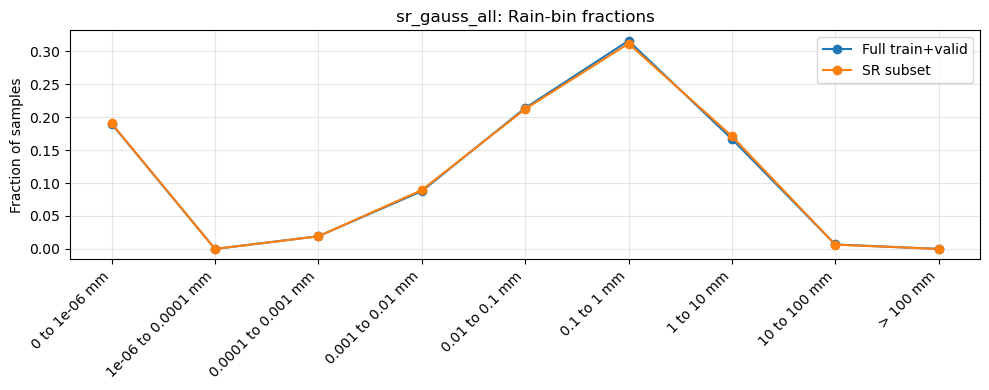

In [8]:
plot_table = bin_table.copy()
x = np.arange(len(plot_table))

full_frac = plot_table["full_frac"].to_numpy()
subset_frac = plot_table["subset_frac"].to_numpy()
labels = plot_table["bin"].astype(str).to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(x, full_frac, marker="o", label="Full train+valid")
plt.plot(x, subset_frac, marker="o", label="SR subset")
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Fraction of samples")
plt.title(f"{run_name}: Rain-bin fractions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()